---

# 🎓 Coursework: Machine Learning and Neural Networks (7PAM2021-0105-2025)
## **Understanding Random Forests: A Practical Tutorial on Attribute Bagging and Variance Reduction**

**Author:** Deshan Chathuranga Herath Pathiranage  
**Student ID:** 24178639  
**GitHub Repository:** [Random Forest Algorithm with Attribute Bagging](https://github.com/Deshan-Chathuranga/Random_Forest_Algorithm_With_Attribute_Bagging.git)

---

In [2]:
#Import python libraries and models
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, accuracy_score, recall_score,
                             precision_score, classification_report, confusion_matrix)

# Create the plots folder if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')

In [5]:


# 1. DATA PREPARATION & CLEANING
df = pd.read_csv('customer_churn_business_dataset.csv')
df.info()


df['complaint_type'] = df['complaint_type'].fillna('None')

# Encoding categorical variables
le = LabelEncoder()
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

# Stratified split to maintain churn ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null 

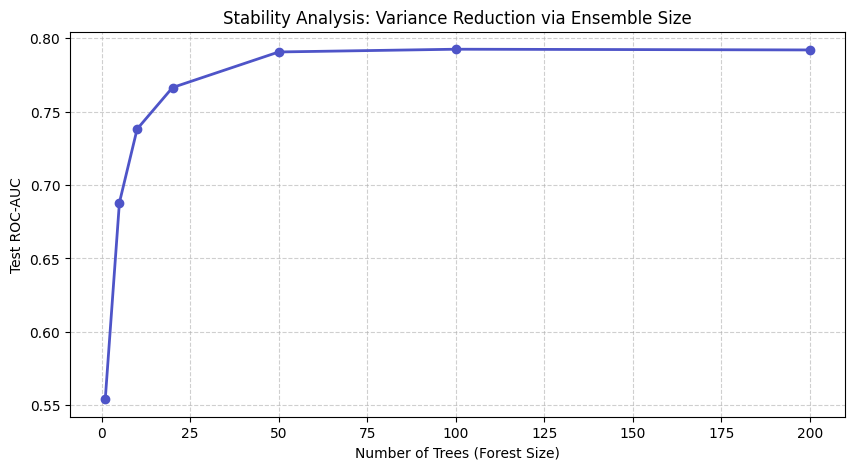

In [6]:
# 2. STABILITY ANALYSIS: The Effect of Forest Size
# We demonstrate how increasing the number of trees stabilizes the model
tree_counts = [1, 5, 10, 20, 50, 100, 200]
auc_scores = []

for n in tree_counts:
    # max_features='sqrt' triggers the Attribute Bagging mechanism
    model = RandomForestClassifier(n_estimators=n, max_features='sqrt', random_state=42)
    model.fit(X_train, y_train)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    auc_scores.append(auc)

plt.figure(figsize=(10, 5))
plt.plot(tree_counts, auc_scores, marker='o', color='#4e54c8', linewidth=2)
plt.title('Stability Analysis: Variance Reduction via Ensemble Size')
plt.xlabel('Number of Trees (Forest Size)')
plt.ylabel('Test ROC-AUC')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- Model Performance Results ---
Accuracy:  0.8985
Recall:    0.0147
Precision: 0.6000


/tmp/ipykernel_2082/1953976277.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=X.columns[indices][:10], palette='viridis')


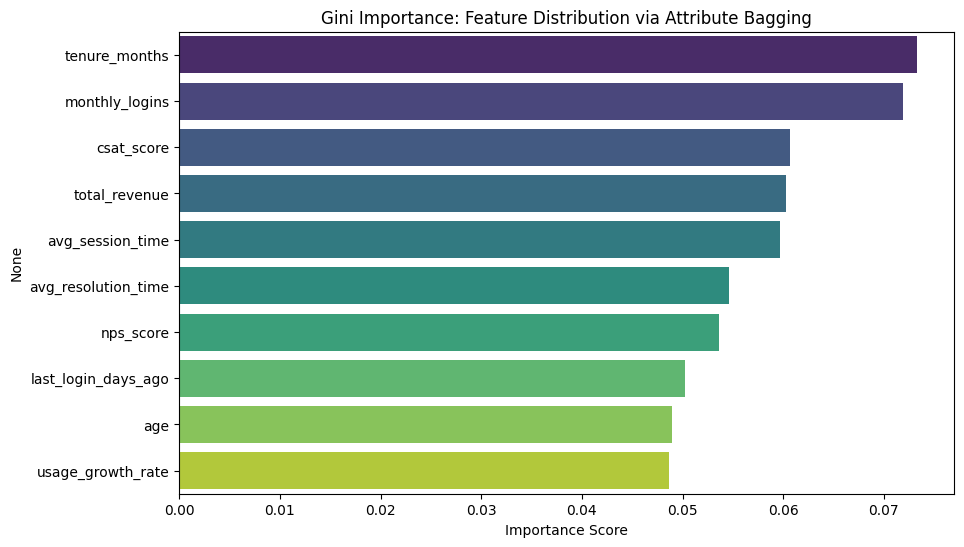

In [11]:
# 3. VISUALIZING ATTRIBUTE BAGGING: Feature Importance
# This shows how the 'Forest' distributes importance across features
rf_final = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)
rf_final.fit(X_train, y_train)



importances = rf_final.feature_importances_
indices = np.argsort(importances)[::-1]



plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:10], y=X.columns[indices][:10], palette='viridis')
plt.title("Gini Importance: Feature Distribution via Attribute Bagging")
plt.xlabel('Importance Score')
plt.show()

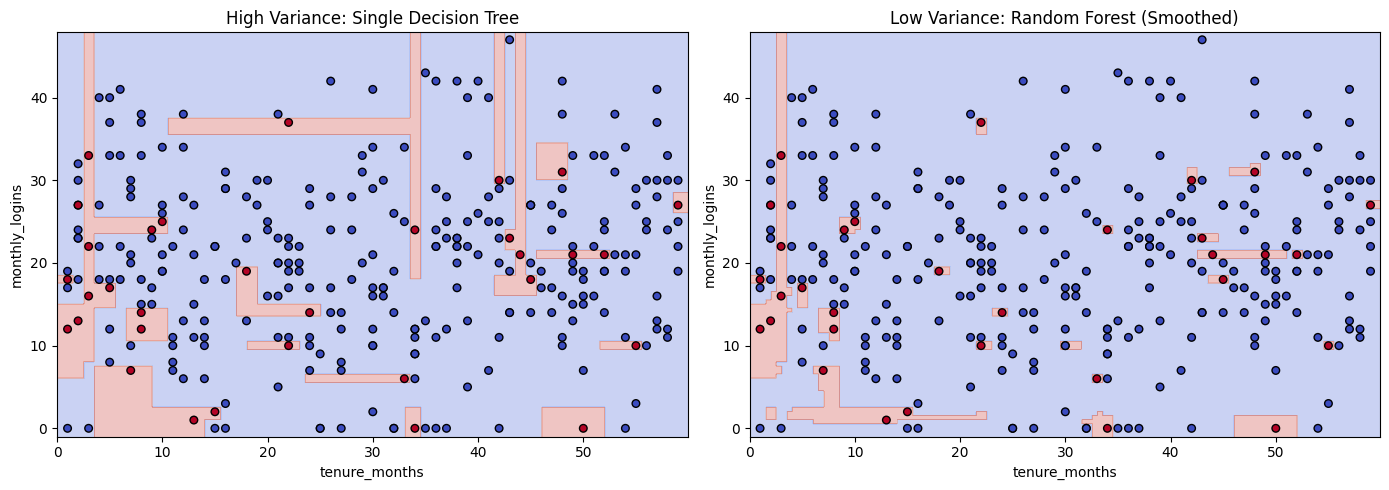

In [7]:
# 4. DECISION BOUNDARY COMPARISON: Single Tree vs. Random Forest
# We select the top 2 features to visualize how the ensemble "smooths" the noise
top_2 = X.columns[indices][:2]
X_vis = X_train[top_2].values[:300] # Subset for clarity
y_vis = y_train.values[:300]

def plot_decision_boundary(clf, title):
    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, edgecolor='k', s=30, cmap='coolwarm')
    plt.title(title)
    plt.xlabel(top_2[0])
    plt.ylabel(top_2[1])

plt.figure(figsize=(14, 5))

# High Variance: Single Tree
plt.subplot(1, 2, 1)
tree = DecisionTreeClassifier(random_state=42).fit(X_vis, y_vis)
plot_decision_boundary(tree, "High Variance: Single Decision Tree")

# Low Variance: Random Forest
plt.subplot(1, 2, 2)
rf_vis = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42).fit(X_vis, y_vis)
plot_decision_boundary(rf_vis, "Low Variance: Random Forest (Smoothed)")

plt.tight_layout()
plt.show()

In [8]:

# 5. BUSINESS INTELLIGENCE: Feature Importance via Gini Impurity
# This uses the built-in attribute of the Random Forest model
importances = rf_final.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Create a clean DataFrame for the summary
importance_summary = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

print("--- Top 10 Drivers of Customer Churn ---")
print(importance_summary.head(10))


--- Top 10 Drivers of Customer Churn ---
               Feature  Importance
0        tenure_months    0.073322
1       monthly_logins    0.071873
2           csat_score    0.060627
3        total_revenue    0.060224
4     avg_session_time    0.059710
5  avg_resolution_time    0.054617
6            nps_score    0.053610
7  last_login_days_ago    0.050216
8                  age    0.048994
9    usage_growth_rate    0.048622
